<a href="https://colab.research.google.com/github/soyeonimu/Codeit_Sprint/blob/main/%5B%EC%8A%A4%ED%94%84%EB%A6%B0%ED%8A%B8%EB%AF%B8%EC%85%98%5D12_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8_1%E1%84%90%E1%85%B5%E1%86%B7_%E1%84%80%E1%85%B5%E1%86%B7%E1%84%89%E1%85%A9%E1%84%8B%E1%85%A7%E1%86%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 스프린트 미션 12
***
[미션 배경]  
회사의 규모 성장을 위해 단기적인 현금 보유가 필요한 상황입니다. 서비스에서 제공하고 있는 멤버십 옵션은 1개월 또는 12개월입니다. C-level들은 12개월 단위로 결제하는 구독자의 비율을 늘린다면 단기적으로 현금 흐름이 개선될 것으로 기대하고 있습니다.

이에 따라 여러분이 속한 DA 팀에서는 멤버십 결제 페이지를 개선하기로 했습니다. 멤버십 옵션을 사용자에게 제시하는 방식에 변화를 줌으로써, 12개월 멤버십의 구독 비율을 높이고자합니다.

위에서 가정한 비즈니스 상황과 아래 제시할 실험 개요, 제공해드린 데이터를 기반으로 A/B 테스트의 분석 결과를 제시하고 이에 따른 의사 결정을 제안해보세요.

***
[데이터 개요]  
30일 동안 일별 데이터를 수집했습니다.  
각 날짜마다:
- 페이지 방문자 수
- 구독 전환율: 페이지 방문자 중 실제 구독을 완료한 비율.
- 구독자 수: 1개월 및 12개월 구독자 수.
- 수익: 각 실험안에서 발생한 총 수익.

[실험 기간]
- 2023년 9월 15일 ~ 2023년 10월 14일 (30일간).

***
[목표]
- 12개월 멤버십 구독 비율을 높여 단기적인 현금 흐름을 개선하고, A/B 테스트 결과를 분석하여 의사결정을 제안.

***

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'

# 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style="whitegrid", palette='Accent')


In [ ]:
df = pd.read_csv('30%20Day%20Subscription%20Data.csv')
df

,Unnamed: 0,Date,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,Group,Conversion Rate,1-Month Revenue,12-Month Revenue
0,0,2023.9.15,459,22,19,3,1547,A,0.047930,665,882
1,1,2023.9.16,504,26,21,5,2205,A,0.051587,735,1470
2,2,2023.9.17,514,26,22,4,1946,A,0.050584,770,1176
3,3,2023.9.18,482,23,19,4,1841,A,0.047718,665,1176
4,4,2023.9.19,512,25,19,6,2429,A,0.048828,665,1764
5,5,2023.9.20,490,24,20,4,1876,A,0.048980,700,1176
6,6,2023.9.21,539,25,23,2,1393,A,0.046382,805,588
7,7,2023.9.22,450,21,18,3,1512,A,0.046667,630,882
8,8,2023.9.23,446,22,18,4,1806,A,0.049327,630,1176
9,9,2023.9.24,540,25,21,4,1911,A,0.046296,735,1176


In [ ]:
df.loc[df['Date'] == '2023.9.15']

,Unnamed: 0,Date,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,Group,Conversion Rate,1-Month Revenue,12-Month Revenue
0,0,2023.9.15,459,22,19,3,1547,A,0.047930,665,882
30,0,2023.9.15,516,35,28,7,3038,B,0.067829,980,2058


# EDA

In [ ]:
df.columns

Index(['Unnamed: 0', 'Date', 'Total Users', 'Subscribers',
       '1-Month Subscribers', '12-Month Subscribers', 'Revenue', 'Group',
       'Conversion Rate', '1-Month Revenue', '12-Month Revenue'],
      dtype='object')

index | 날짜 | 총 사용자 수 | 구독자 수 | 1개월 구독자 수 | 12개월 구독자 수 | 수익 | 그룹 | 전환율 | 1개월 수익 | 12개월 수익

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            60 non-null     int64  
 1   Date                  60 non-null     object 
 2   Total Users           60 non-null     int64  
 3   Subscribers           60 non-null     int64  
 4   1-Month Subscribers   60 non-null     int64  
 5   12-Month Subscribers  60 non-null     int64  
 6   Revenue               60 non-null     int64  
 7   Group                 60 non-null     object 
 8   Conversion Rate       60 non-null     float64
 9   1-Month Revenue       60 non-null     int64  
 10  12-Month Revenue      60 non-null     int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 5.3+ KB


In [ ]:
df.describe()

,Unnamed: 0,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,Conversion Rate,1-Month Revenue,12-Month Revenue
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.00000
mean,14.500000,507.450000,29.666667,24.183333,5.483333,2458.516667,0.058497,846.416667,1612.10000
std,8.728484,42.213109,5.697655,4.515479,2.062512,687.849917,0.010425,158.041755,606.37846
min,0.000000,424.000000,20.000000,17.000000,2.000000,1323.000000,0.044944,595.000000,588.00000
25%,7.000000,480.500000,25.000000,20.000000,4.000000,1867.250000,0.048701,700.000000,1176.00000
50%,14.500000,512.000000,30.000000,24.000000,5.000000,2415.000000,0.055037,840.000000,1470.00000
75%,22.000000,528.750000,35.000000,28.000000,7.000000,2924.250000,0.068341,980.000000,2058.00000
max,29.000000,607.000000,39.000000,35.000000,11.000000,4214.000000,0.077381,1225.000000,3234.00000


---
## 결측값

In [ ]:
df.isna().sum()

Unnamed: 0              0
Date                    0
Total Users             0
Subscribers             0
1-Month Subscribers     0
12-Month Subscribers    0
Revenue                 0
Group                   0
Conversion Rate         0
1-Month Revenue         0
12-Month Revenue        0
dtype: int64

---
## 중복값

In [ ]:
df.duplicated().sum()

np.int64(0)

***
## 이상치

In [ ]:
df.columns

Index(['Unnamed: 0', 'Date', 'Total Users', 'Subscribers',
       '1-Month Subscribers', '12-Month Subscribers', 'Revenue', 'Group',
       'Conversion Rate', '1-Month Revenue', '12-Month Revenue'],
      dtype='object')

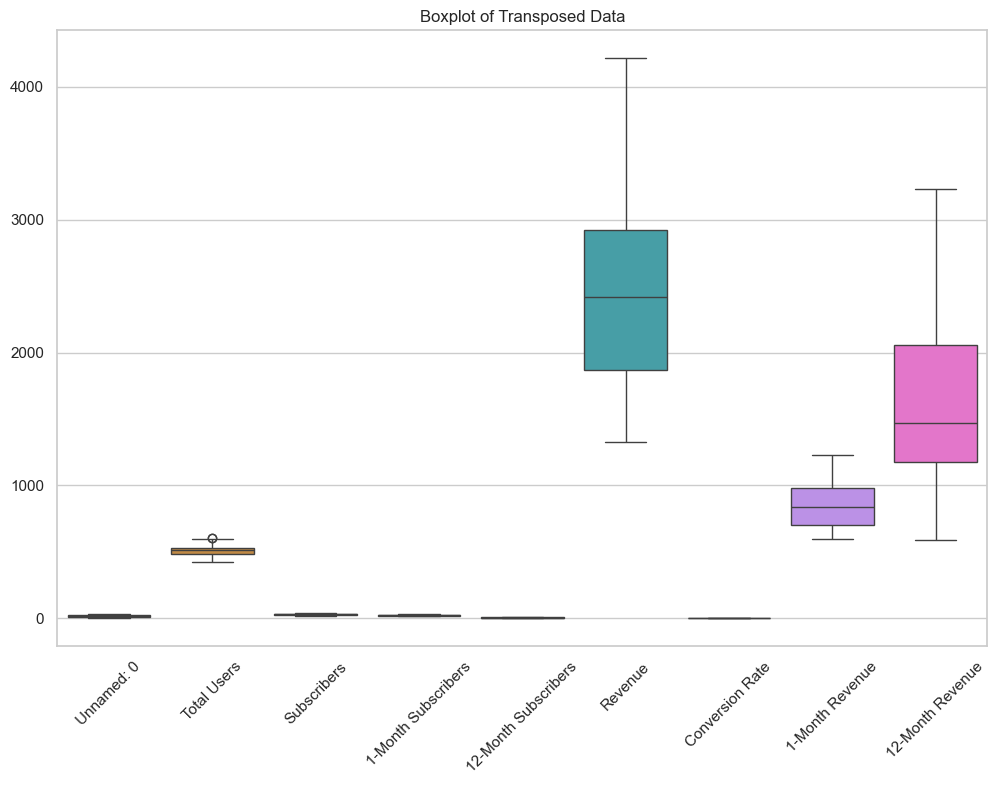

In [ ]:
df_numeric = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_numeric)
plt.title('Boxplot of Transposed Data')
plt.xticks(rotation=45)
plt.show()

***
## 그룹별 데이터 비교

In [ ]:
grouped = df.groupby('Group')

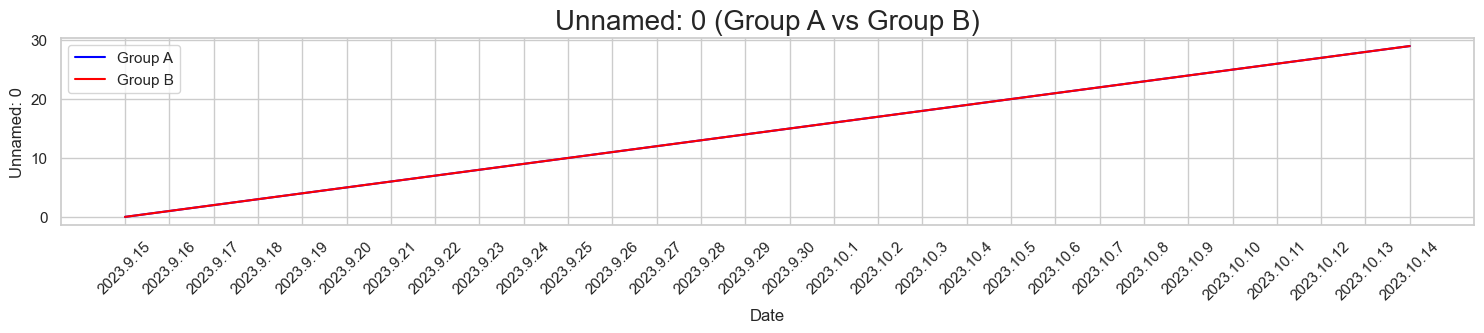

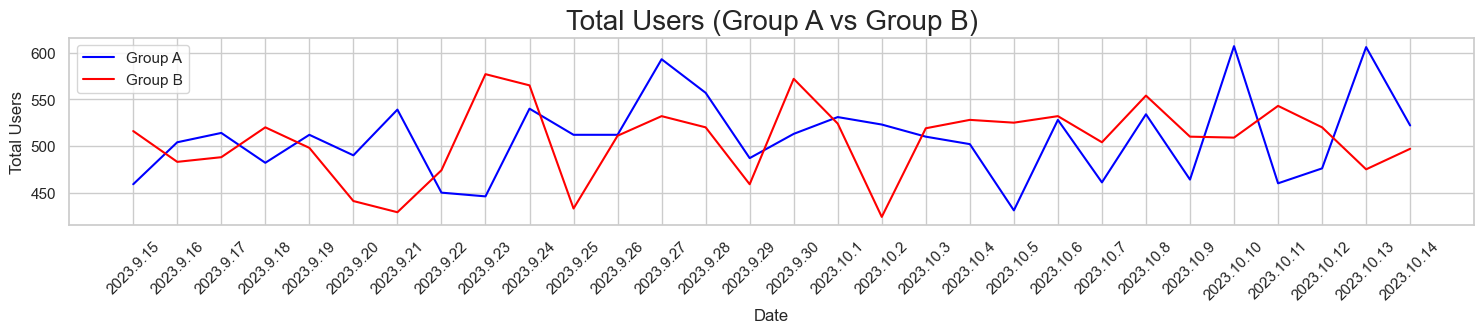

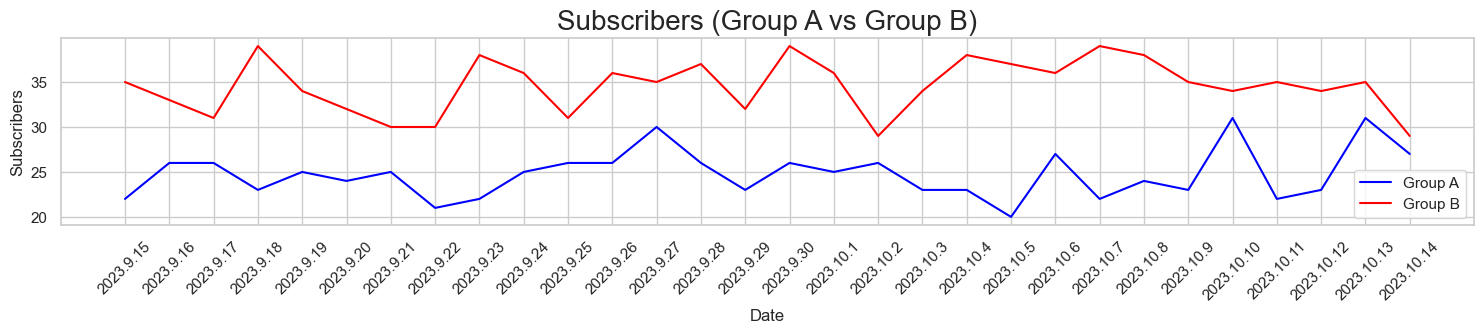

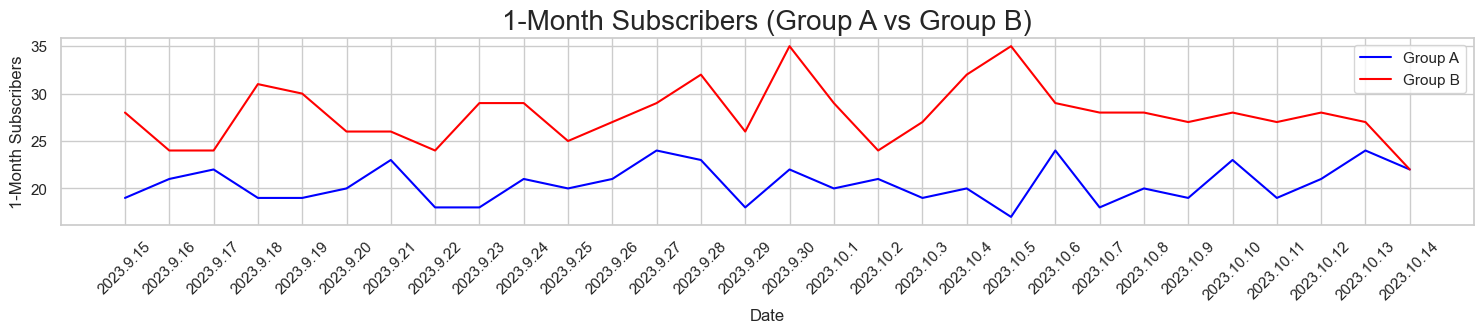

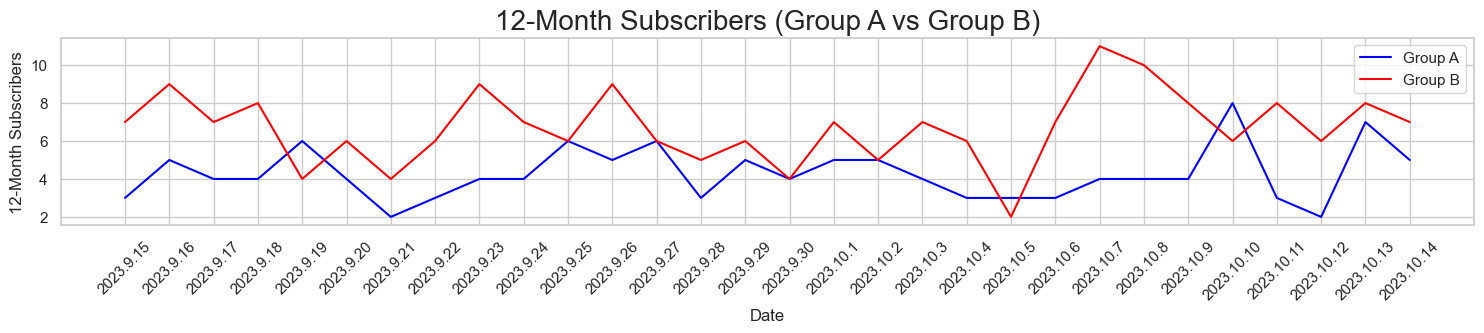

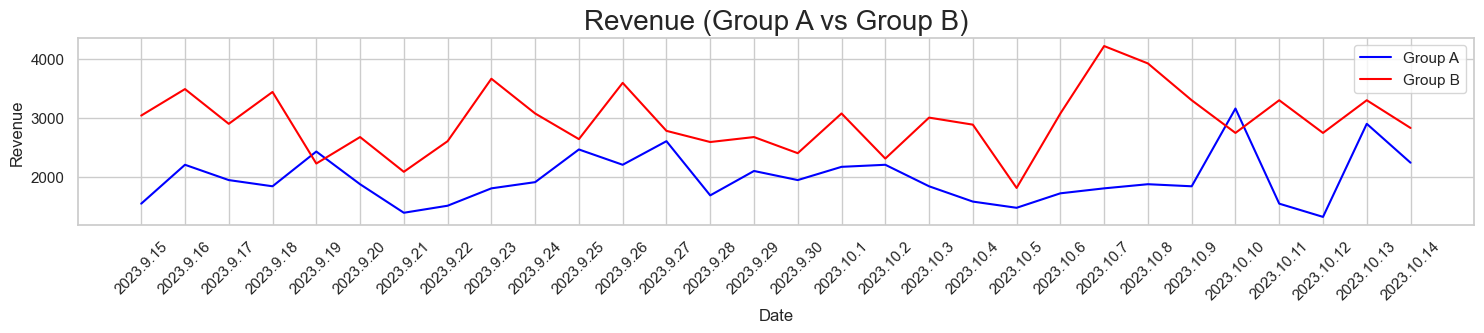

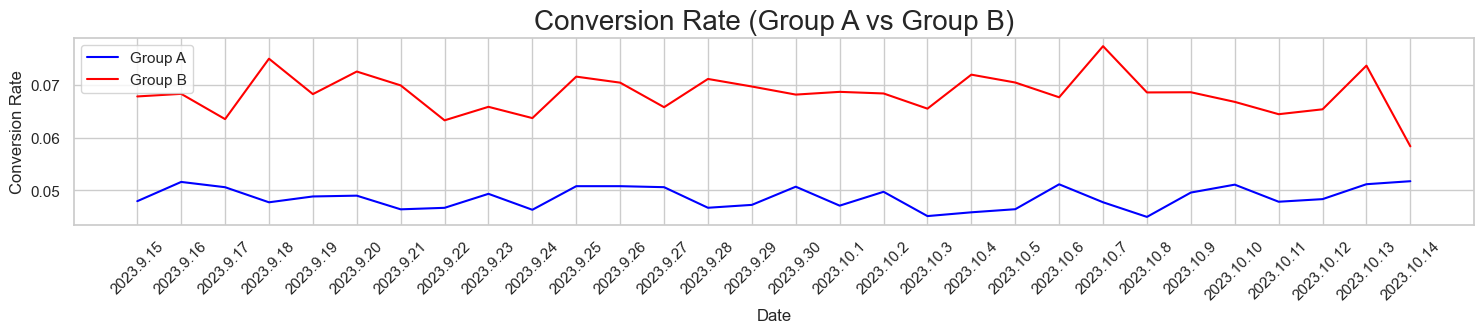

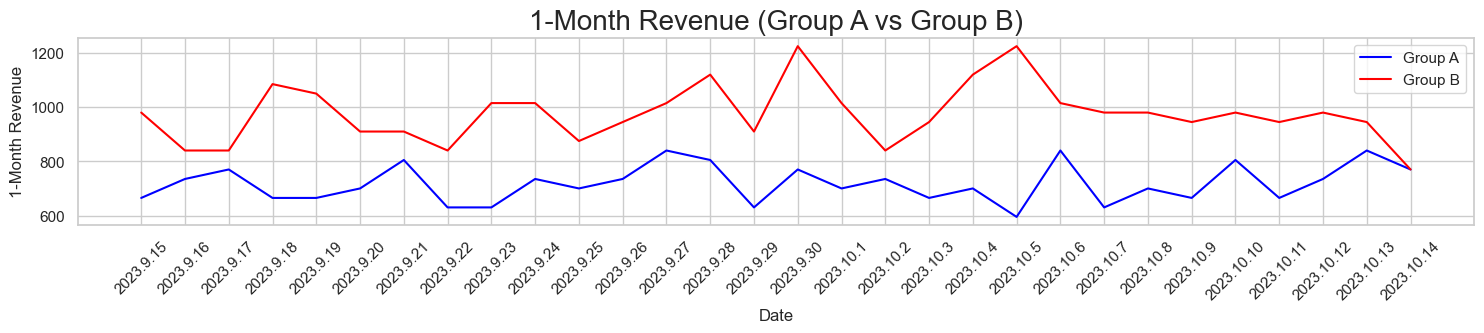

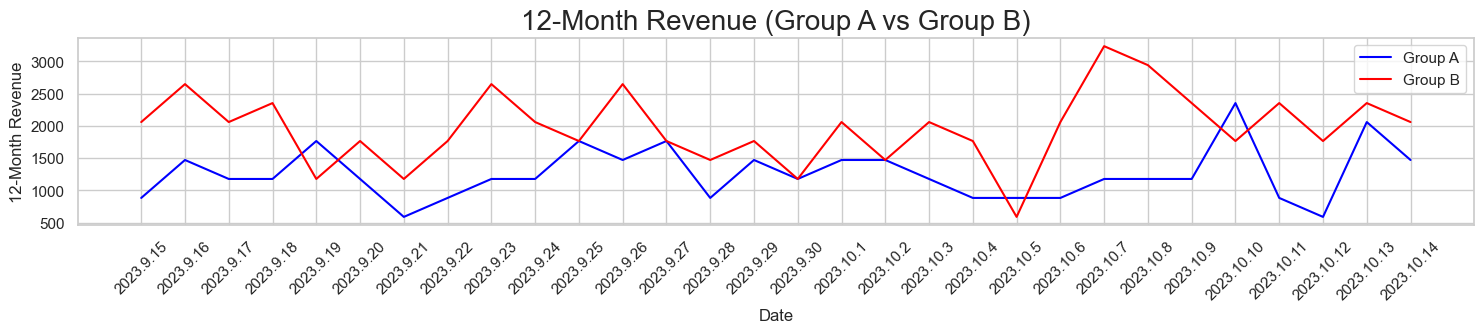

In [ ]:
# 딕셔너리 컴프리헨션
grouped_dict = {group_name: group_data for group_name, group_data in grouped}

# A/B 그룹 번갈아 시각화
for i in df_numeric:
    plt.figure(figsize=(15, 3))

    # A 그룹 시각화
    sns.lineplot(x='Date', y=i, data=grouped_dict['A'], label='Group A', color='blue')
    # B 그룹 시각화
    sns.lineplot(x='Date', y=i, data=grouped_dict['B'], label='Group B', color='red')

    plt.title(f'{i} (Group A vs Group B)', fontsize=20)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()


- 전체적으로 B안의 성과가 좋다

***
# 이용분석

In [ ]:
df['Non-Subscribers'] = df['Total Users']-df['Subscribers']

In [ ]:
# Melt 데이터를 준비하여 long-format으로 변환
long_format = df.melt(
    id_vars=['Date'],
    value_vars=['Subscribers', 'Non-Subscribers'],
    var_name='Group',
    value_name='Count'
)

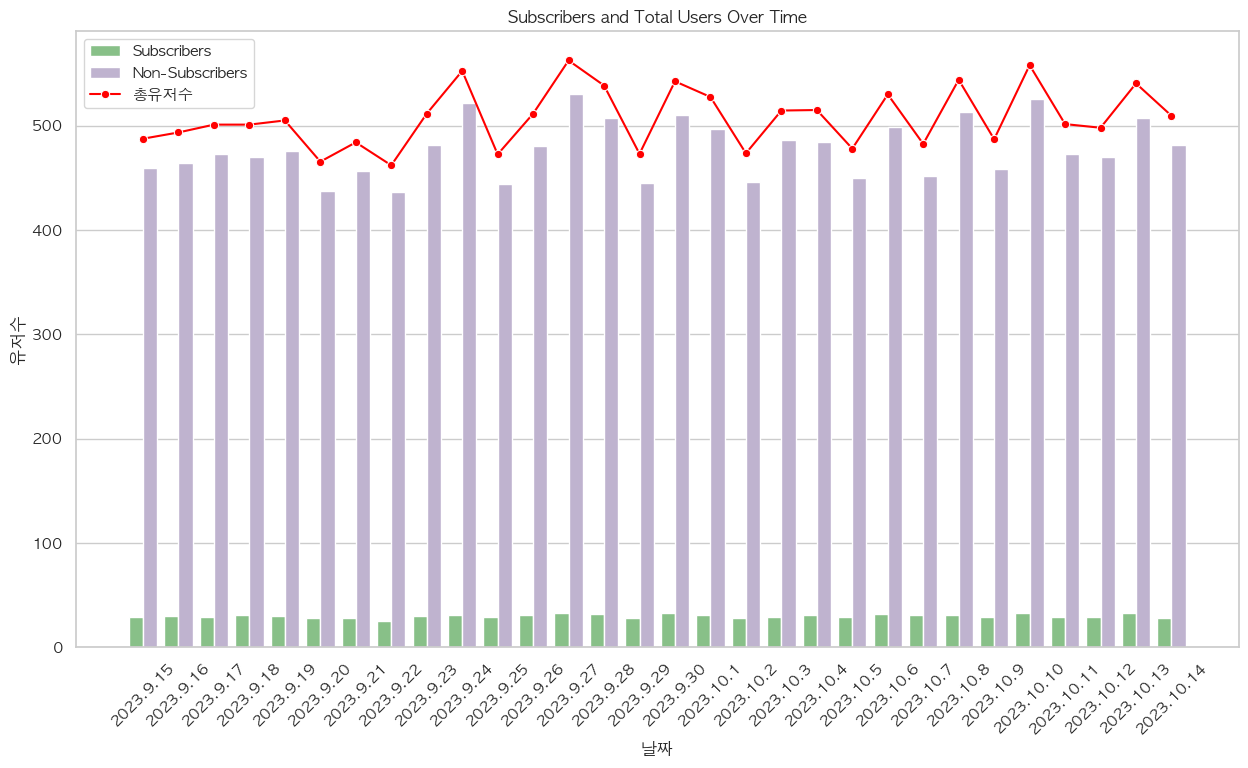

In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'
fig, ax = plt.subplots(figsize=(15, 8))

# 바 그래프
sns.barplot(data=long_format,x='Date',y='Count',hue='Group',ax=ax, errorbar=None)

# 총 유저수 라인 그래프
sns.lineplot(data=df,x='Date', y='Total Users', ax=ax, marker='o', label='총유저수', color='red',errorbar=None)

# 그래프 설정
plt.xticks(rotation=45)
ax.set_xlabel('날짜')
ax.set_ylabel('유저수')
ax.set_title('Subscribers and Total Users Over Time')
ax.legend()

plt.show()

***
# 전환율 분석

In [ ]:
# 그룹별 집계
group_summary = df.groupby('Group').agg({
    'Total Users': 'sum',
    'Subscribers': 'sum',
    '1-Month Subscribers': 'sum',
    '12-Month Subscribers': 'sum',
    'Revenue': 'sum',
    'Conversion Rate': 'mean'
}).reset_index()
group_summary

,Group,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,Conversion Rate
0,A,15265,743,615,128,59157,0.048621
1,B,15182,1037,836,201,88354,0.068373


In [ ]:
from scipy.stats import ttest_ind

group_a_conversion = df[df['Group'] == 'A']['Conversion Rate']
group_b_conversion = df[df['Group'] == 'B']['Conversion Rate']

t_stat, p_value = ttest_ind(group_a_conversion, group_b_conversion, equal_var=True)

print("[전환율 t-Test 결과]")
print("- t-statistic =", t_stat)
print("- p-value =", p_value)

if p_value < 0.05:
    print("전환율의 차이는 통계적으로 유의미합니다.")
else:
    print("전환율의 차이는 통계적으로 유의미하지 않습니다.")


[전환율 t-Test 결과]
- t-statistic = -24.610705990664677
- p-value = 2.1877611130738092e-32
전환율의 차이는 통계적으로 유의미합니다.


***
# 구독자 비율 분석

In [ ]:
df['1-Month Rate'] = (df['1-Month Subscribers'] / df['Subscribers']) * 100
df['12-Month Rate'] = (df['12-Month Subscribers'] / df['Subscribers']) * 100

In [ ]:
# 그룹별 1개월 및 12개월 구독 비율 평균
group_rates = df.groupby('Group')[['1-Month Rate', '12-Month Rate']].mean()
group_rates

,1-Month Rate,12-Month Rate
Group,,
A,82.966626,17.033374
B,80.606724,19.393276


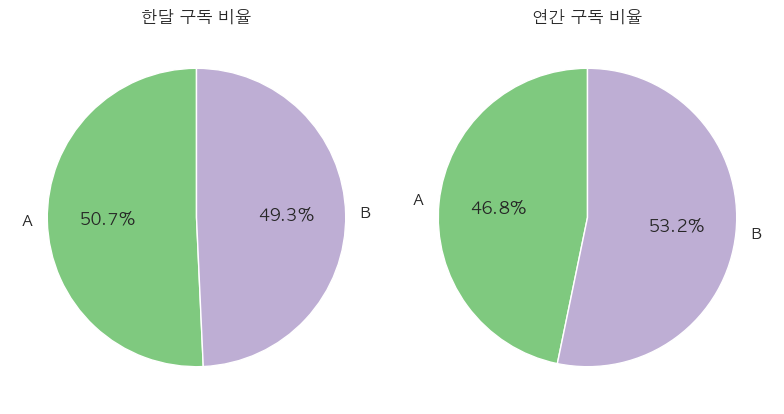

In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'

# 그룹별 평균 비율 계산
group_rates = df.groupby('Group')[['1-Month Rate', '12-Month Rate']].mean()

# 원형 차트 생성
plt.figure(figsize=(8, 6))

# 1개월 구독 비율
plt.subplot(1, 2, 1)
plt.pie(
    group_rates['1-Month Rate'],
    labels=group_rates.index,
    autopct='%1.1f%%',
    startangle=90,
)
plt.title("한달 구독 비율")

# 12개월 구독 비율
plt.subplot(1, 2, 2)
plt.pie(
    group_rates['12-Month Rate'],
    labels=group_rates.index,
    autopct='%1.1f%%',
    startangle=90,
)
plt.title("연간 구독 비율")

plt.tight_layout()
plt.show()


***
### `한달구독` 비율

In [ ]:
# 그룹별 한달구독 비율 비교
group_1_month_rate = df.groupby('Group')['1-Month Rate'].mean().reset_index()
group_1_month_rate

,Group,1-Month Rate
0,A,82.966626
1,B,80.606724


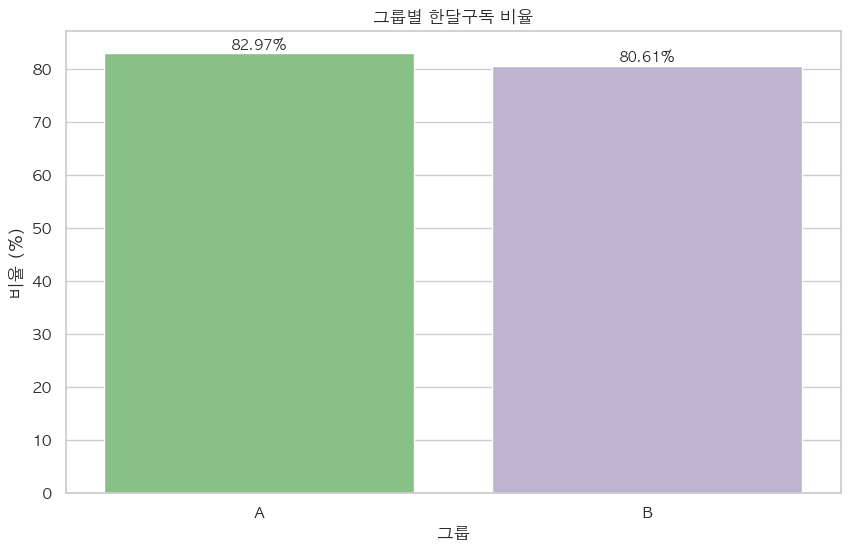

In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'
# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=group_1_month_rate, x='Group', y='1-Month Rate', hue='Group')

# bar_label로 값 표시
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=10)
ax.bar_label(ax.containers[1], fmt="%.2f%%", label_type="edge", fontsize=10)

# 제목 및 레이블 설정
plt.title("그룹별 한달구독 비율")
plt.ylabel("비율 (%)")
plt.xlabel("그룹")

# 그래프 표시
plt.show()


In [ ]:
group_a_1month = df[df['Group'] == 'A']['1-Month Rate']
group_b_1month = df[df['Group'] == 'B']['1-Month Rate']

t_stat_1m, p_value_1m = ttest_ind(group_a_1month, group_b_1month)

print("[1개월 구독 비율 t-Test 결과]")
print("- t-statistic =", t_stat_1m)
print("- p-value =", p_value_1m)

[1개월 구독 비율 t-Test 결과]
- t-statistic = 1.950201592438778
- p-value = 0.05599069757371794


___
### `연간구독` 비율

In [ ]:
# 그룹별 연간구독 비율 비교
group_12_month_rate = df.groupby('Group')['12-Month Rate'].mean().reset_index()
group_12_month_rate

,Group,12-Month Rate
0,A,17.033374
1,B,19.393276


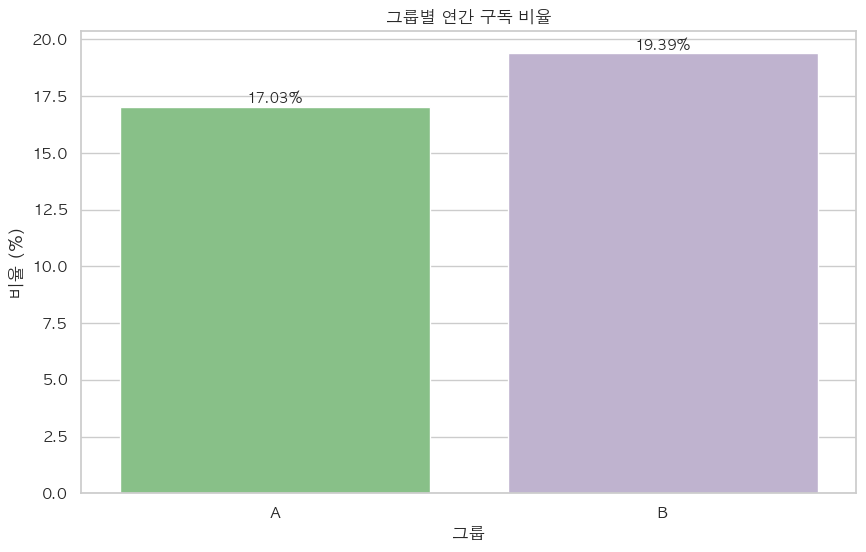

In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'
# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=group_12_month_rate, x='Group', y='12-Month Rate', hue='Group')

# bar_label로 값 표시
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=10)
ax.bar_label(ax.containers[1], fmt="%.2f%%", label_type="edge", fontsize=10)

# 제목 및 레이블 설정
plt.title("그룹별 연간 구독 비율")
plt.ylabel("비율 (%)")
plt.xlabel("그룹")

# 그래프 표시
plt.show()


In [ ]:
group_a_12month = df[df['Group'] == 'A']['12-Month Rate']
group_b_12month = df[df['Group'] == 'B']['12-Month Rate']

t_stat_12m, p_value_12m = ttest_ind(group_a_12month, group_b_12month)

print("[12개월 구독 비율 t-Test 결과]")
print("- t-statistic =", t_stat_12m)
print("- p-value =", p_value_12m)

[12개월 구독 비율 t-Test 결과]
- t-statistic = -1.9502015924387925
- p-value = 0.055990697573716205


***
# 수익분석

In [ ]:
# 그룹별 1개월 및 12개월 수익 비율
df['1-Month Revenue Rate'] = (df['1-Month Revenue'] / df['Revenue']) * 100
df['12-Month Revenue Rate'] = (df['12-Month Revenue'] / df['Revenue']) * 100

In [ ]:
# 그룹별 1개월 및 12개월 수익 비율 평균
group_revenue_rates = df.groupby('Group')[['1-Month Revenue Rate', '12-Month Revenue Rate']].mean()
group_revenue_rates

,1-Month Revenue Rate,12-Month Revenue Rate
Group,,
A,37.717806,62.282194
B,34.407683,65.592317


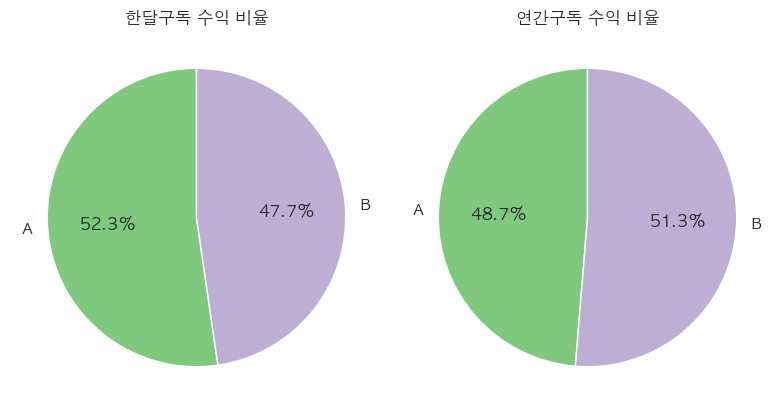

In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'

# 원형 차트 생성
plt.figure(figsize=(8,6))

# 1개월 수익 비율
plt.subplot(1, 2, 1)
plt.pie(
    group_revenue_rates['1-Month Revenue Rate'],
    labels=group_revenue_rates.index,
    autopct='%1.1f%%',
    startangle=90,
)
plt.title("한달구독 수익 비율")

# 12개월 수익 비율
plt.subplot(1, 2, 2)
plt.pie(
    group_revenue_rates['12-Month Revenue Rate'],
    labels=group_revenue_rates.index,
    autopct='%1.1f%%',
    startangle=90,
)
plt.title("연간구독 수익 비율")

plt.tight_layout()
plt.show()


***
### `한달수익` 비율

In [ ]:
# 그룹별 한달구독 비율 비교
group_1_month_rate = df.groupby('Group')['1-Month Revenue Rate'].mean().reset_index()
group_1_month_rate

,Group,1-Month Revenue Rate
0,A,37.717806
1,B,34.407683


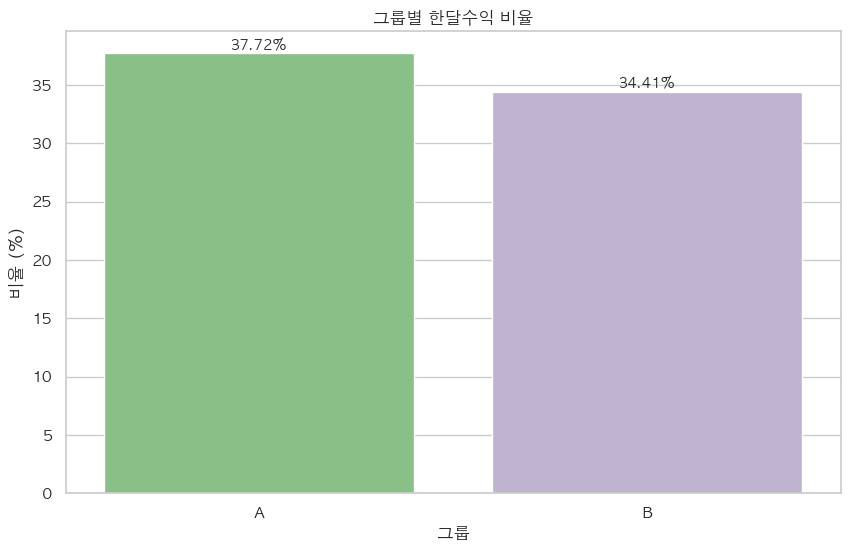

In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'

# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=group_1_month_rate, x='Group', y='1-Month Revenue Rate', hue='Group')

# bar_label로 값 표시
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=10)
ax.bar_label(ax.containers[1], fmt="%.2f%%", label_type="edge", fontsize=10)

# 제목 및 레이블 설정
plt.title("그룹별 한달수익 비율")
plt.ylabel("비율 (%)")
plt.xlabel("그룹")

# 그래프 표시
plt.show()


In [ ]:
group_a_1month = df[df['Group'] == 'A']['1-Month Revenue Rate']
group_b_1month = df[df['Group'] == 'B']['1-Month Revenue Rate']


print("[1개월 구독 비율 t-Test 결과]")
print("- t-statistic =", t_stat_1m)
print("- p-value =", p_value_1m)

[1개월 구독 비율 t-Test 결과]
- t-statistic = 1.950201592438778
- p-value = 0.05599069757371794


___
### `연간수익` 비율

In [ ]:
# 그룹별 연간구독 비율 비교
group_12_month_rate = df.groupby('Group')['12-Month Revenue Rate'].mean().reset_index()
group_12_month_rate

,Group,12-Month Revenue Rate
0,A,62.282194
1,B,65.592317


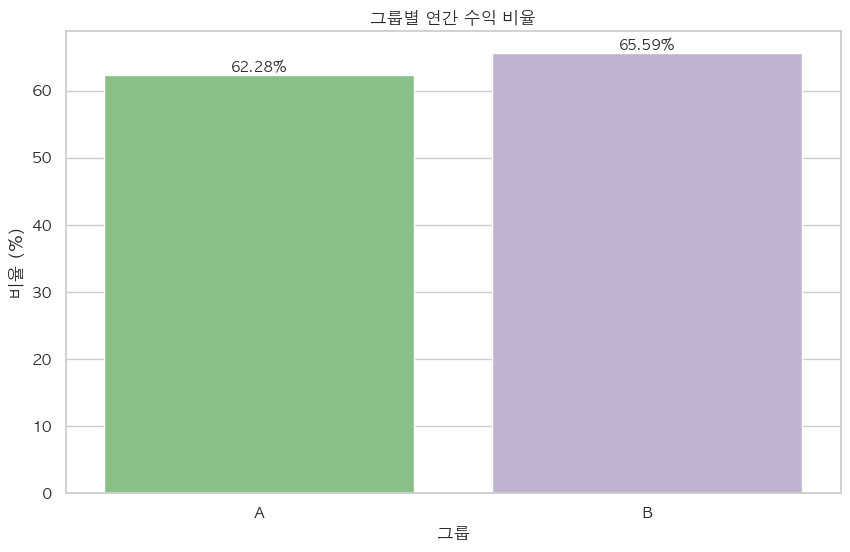

In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'
# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=group_12_month_rate, x='Group', y='12-Month Revenue Rate', hue='Group')

# bar_label로 값 표시
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=10)
ax.bar_label(ax.containers[1], fmt="%.2f%%", label_type="edge", fontsize=10)

# 제목 및 레이블 설정
plt.title("그룹별 연간 수익 비율")
plt.ylabel("비율 (%)")
plt.xlabel("그룹")

# 그래프 표시
plt.show()


In [ ]:
group_a_12month = df[df['Group'] == 'A']['12-Month Revenue Rate']
group_b_12month = df[df['Group'] == 'B']['12-Month Revenue Rate']

t_stat_12m, p_value_12m = ttest_ind(group_a_12month, group_b_12month)

print("[12개월 구독 비율 t-Test 결과]")
print("- t-statistic =", t_stat_12m)
print("- p-value =", p_value_12m)

[12개월 구독 비율 t-Test 결과]
- t-statistic = -1.528921033369014
- p-value = 0.13171993140146304


***
# 사용자당 수익 비율

In [ ]:
# 사용자당 평균 수익(ARPU)
df['ARPU'] = df['Revenue'] / df['Total Users']

In [ ]:
# 그룹별 평균 ARPU 계산
group_arpu = df.groupby('Group')['ARPU'].mean()

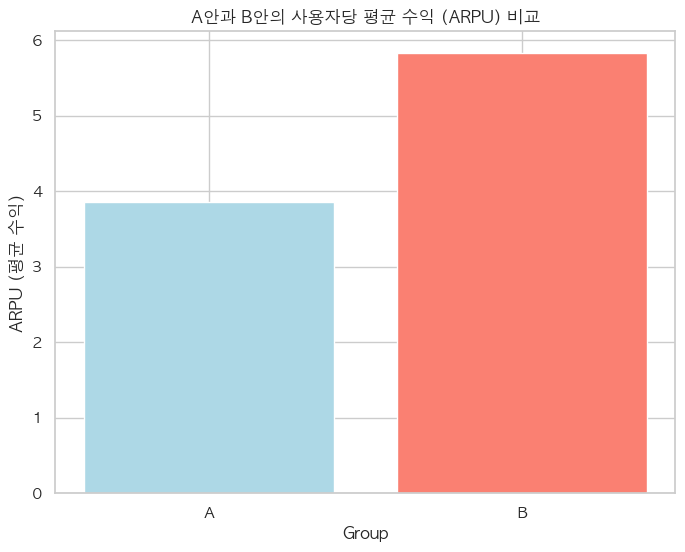

In [ ]:
# ARPU 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar(group_arpu.index, group_arpu, color=['lightblue', 'salmon'])
plt.title("A안과 B안의 사용자당 평균 수익 (ARPU) 비교")
plt.ylabel("ARPU (평균 수익)")
plt.xlabel("Group")
plt.show()

In [ ]:
from scipy.stats import ttest_ind, chi2_contingency

# 그룹별 ARPU 비교
group_a_arpu = df[df['Group'] == 'A']['ARPU']
group_b_arpu = df[df['Group'] == 'B']['ARPU']

t_stat, p_value = ttest_ind(group_a_arpu, group_b_arpu)

print("[ARPU t-Test 결과]")
print("- t-statistic =", t_stat)
print("- p-value =", p_value)

if p_value < 0.05:
    print("ARPU 차이가 통계적으로 유의미합니다.")
else:
    print("ARPU 차이가 통계적으로 유의미하지 않습니다.")

[ARPU t-Test 결과]
- t-statistic = -9.353281132241792
- p-value = 3.4825847643136875e-13
ARPU 차이가 통계적으로 유의미합니다.


***
## **결론: B안 채택 여부 및 추가 실험 제안**

### **B안 채택 여부**
1. **12개월 구독 비율 증가**:
   - 통계적 검정 결과, B안에서 **12개월 구독 비율이 A안보다 유의미하게 증가**했습니다.
   - 이는 12개월 구독 비율을 높이는 것이 목표인 비즈니스 요구에 부합합니다.

2. **사용자당 평균 수익(ARPU) 증가**:
   - B안에서 사용자당 평균 수익(ARPU)이 A안보다 유의미하게 높았습니다.
   - 이는 단기적인 현금 흐름 개선이라는 목표를 직접적으로 지원합니다.

3. **결론**:
   - 위 결과를 바탕으로, **B안을 채택하는 것이 비즈니스 목표(12개월 구독 비율 증가 및 현금 흐름 개선)에 더 적합**합니다.

---

### **추가 실험 필요성**
#### 1. **장기 효과 평가**:
   - 현재 실험은 30일 동안의 데이터를 기반으로 분석되었습니다.
   - 12개월 구독 비율이 높더라도, **장기적으로 사용자 이탈률이 증가**한다면 수익성에 부정적인 영향을 미칠 수 있습니다.
   - 이를 평가하기 위해 **장기적인 구독 유지율(cohort analysis)** 실험을 추가로 진행할 필요가 있습니다.

#### 2. **다른 변수 실험**:
   - 페이지 디자인 외에도 **가격 정책**, **프로모션 전략**, **광고 메시지** 등 다른 요인들이 수익에 미치는 영향을 확인할 필요가 있습니다.

#### 3. **사용자 세그먼트별 분석**:
   - B안이 모든 사용자 그룹(예: 연령대, 지역, 구독 경험)에 동일한 영향을 미쳤는지 확인하기 위해 세그먼트별 추가 실험이 필요합니다.
   - 특정 세그먼트에서 더 큰 효과를 보였다면, 이를 강화하는 전략을 설계할 수 있습니다.

---